# test axial registration

exercises `mbo_utilities.arrays._axial_registration` on an LBM tif.

checks:
1. loads a 4d movie `(nz, nt, ny, nx)`
2. computes plane shifts on cpu
3. computes plane shifts on gpu (if cupy is installed)
4. cpu vs gpu: shifts should match to within 1 pixel
5. against suite3d `summary.npy`: optional, only if a prior s3d run exists
6. visualizes shifts and before/after-shift mean images
7. benchmarks cpu vs gpu runtime

## 1. config

In [4]:
from pathlib import Path

# point this at your LBM tif or directory of tifs
TEST_INPUT = Path("D:/demo/raw")

# optional: path to an existing suite3d summary.npy to compare against
# leave as None to skip that check
S3D_SUMMARY = None  # e.g. Path("D:/demo/bugfix_test/.../summary/summary.npy")

# alignment params (match suite3d defaults for the 3d path)
SIGMA = (1.45, 0)
SMOOTH_SIGMA = 1.15
MAX_REG_XY = 150  # matches your register_zplanes_s3d default

# how many frames to subsample for the time-mean. suite3d's default is 500,
# your register_zplanes_s3d lowered it to 200. fewer frames -> faster, but
# noisier alignment. shift quality saturates quickly (~200-500 is plenty).
MAX_FRAMES = 200

# how many frames to load per chunk while streaming. keep CHUNK * nz * ny * nx * 2
# bytes small enough to fit comfortably in RAM. 20 frames of a (14, 1000, 1000)
# volume = ~560 MB, so 10 is safe even for large tiles.
CHUNK_FRAMES = 10

print(f"input: {TEST_INPUT}")
print(f"exists: {TEST_INPUT.exists()}")

input: D:\demo\raw
exists: True


## 2. load data

In [5]:
import numpy as np
from mbo_utilities import imread

arr = imread(TEST_INPUT)
print(f"type: {type(arr).__name__}")
print(f"shape: {arr.shape}")
print(f"dtype: {arr.dtype}")

Counting frames:   0%|          | 0/2 [00:00<?, ?it/s]

type: LBMArray
shape: (1574, 1, 14, 550, 448)
dtype: int16


In [6]:
# streaming mean: never materialize the full 4d movie.
# we only need im3d = (nz, ny, nx) for plane-shift computation.
# for a (1000, 14, 1000, 1000) int16 dataset that's 56 MB instead of 28 GB.

# resolve (nz, ny, nx) and total frame count from whatever backend we got.
# shape5d is (T, C, Z, Y, X); bare 4d arrays are (T, Z, Y, X).
if hasattr(arr, "shape5d"):
    T, C, Z, Y, X = tuple(arr.shape5d)
    use_5d_index = True
elif arr.ndim == 4:
    T, Z, Y, X = arr.shape
    C = 1
    use_5d_index = False
else:
    raise ValueError(f"unsupported array shape {arr.shape}")

nz, ny, nx = Z, Y, X
n_sub = min(MAX_FRAMES, T) if MAX_FRAMES is not None else T
frame_idx = np.linspace(0, T - 1, n_sub, dtype=int).tolist()

print(f"total frames: {T}   subsample: {n_sub}")
print(f"volume shape per frame: ({nz}, {ny}, {nx})")
print(f"im3d target size: {nz * ny * nx * 4 / 1024**2:.1f} MB  (float32)")

im3d_sum = np.zeros((nz, ny, nx), dtype=np.float64)
count = 0

t0 = time.perf_counter() if "time" in dir() else None
import time  # ensure available if config cell was skipped
t0 = time.perf_counter()

for start in range(0, n_sub, CHUNK_FRAMES):
    idx = frame_idx[start : start + CHUNK_FRAMES]
    if use_5d_index:
        batch = arr[idx]  # (len(idx), C, Z, Y, X)
        batch = np.asarray(batch)
        # collapse C if present and size 1; otherwise take first color
        if batch.ndim == 5:
            batch = batch[:, 0] if batch.shape[1] == 1 else batch[:, 0]
    else:
        batch = np.asarray(arr[idx])  # (len(idx), Z, Y, X)
    im3d_sum += batch.sum(axis=0, dtype=np.float64)
    count += batch.shape[0]
    print(f"  loaded {count}/{n_sub} frames  (batch shape {batch.shape})", end="\r")

im3d = (im3d_sum / count).astype(np.float32)
t_load = time.perf_counter() - t0
print(f"\nstreamed {count} frames in {t_load:.1f}s")
print(f"im3d shape: {im3d.shape}  dtype: {im3d.dtype}  size: {im3d.nbytes / 1024**2:.1f} MB")

total frames: 1574   subsample: 200
volume shape per frame: (14, 550, 448)
im3d target size: 13.2 MB  (float32)
  loaded 200/200 frames  (batch shape (10, 14, 550, 448))
streamed 200 frames in 41.8s
im3d shape: (14, 550, 448)  dtype: float32  size: 13.2 MB


## 3. cpu shifts

In [7]:
import time
from mbo_utilities.arrays._axial_registration import compute_plane_shifts

t0 = time.perf_counter()
tvecs_cpu = compute_plane_shifts(
    im3d,
    sigma=SIGMA,
    smooth_sigma=SMOOTH_SIGMA,
    max_reg_xy=MAX_REG_XY,
    use_gpu=False,
)
t_cpu = time.perf_counter() - t0

print(f"cpu elapsed: {t_cpu:.2f} s")
print(f"tvecs shape: {tvecs_cpu.shape}")
print(f"tvecs dtype: {tvecs_cpu.dtype}")
print(f"y range: [{tvecs_cpu[:, 0].min()}, {tvecs_cpu[:, 0].max()}]")
print(f"x range: [{tvecs_cpu[:, 1].min()}, {tvecs_cpu[:, 1].max()}]")
tvecs_cpu

cpu elapsed: 0.48 s
tvecs shape: (14, 2)
tvecs dtype: int64
y range: [0, 97]
x range: [-5, 0]


array([[ 0,  0],
       [ 8, -1],
       [16, -2],
       [24, -3],
       [32, -4],
       [40, -4],
       [48, -4],
       [55, -4],
       [62, -5],
       [69, -5],
       [76, -5],
       [83, -5],
       [90, -5],
       [97, -5]])

## 4. gpu shifts

skipped automatically if cupy is unavailable.

In [8]:
from mbo_utilities.arrays._axial_registration import HAS_CUPY

tvecs_gpu = None
t_gpu = None

if HAS_CUPY:
    # warm-up: first cupy call jit-compiles kernels and allocates pools
    _ = compute_plane_shifts(
        im3d[:, :32, :32],
        sigma=SIGMA,
        smooth_sigma=SMOOTH_SIGMA,
        max_reg_xy=4,
        use_gpu=True,
    )

    t0 = time.perf_counter()
    tvecs_gpu = compute_plane_shifts(
        im3d,
        sigma=SIGMA,
        smooth_sigma=SMOOTH_SIGMA,
        max_reg_xy=MAX_REG_XY,
        use_gpu=True,
    )
    t_gpu = time.perf_counter() - t0

    print(f"gpu elapsed: {t_gpu:.2f} s  (cpu was {t_cpu:.2f} s, speedup {t_cpu / t_gpu:.1f}x)")
    print(f"tvecs shape: {tvecs_gpu.shape}")
    print(f"tvecs dtype: {tvecs_gpu.dtype}")
else:
    print("cupy not installed -- skipping gpu path")

tvecs_gpu

gpu elapsed: 3.35 s  (cpu was 0.48 s, speedup 0.1x)
tvecs shape: (14, 2)
tvecs dtype: int32


array([[ 0,  0],
       [ 8, -1],
       [16, -2],
       [24, -3],
       [32, -4],
       [40, -4],
       [48, -4],
       [55, -4],
       [62, -5],
       [69, -5],
       [76, -5],
       [83, -5],
       [90, -5],
       [97, -5]], dtype=int32)

## 5. cpu vs gpu parity

phase correlation is integer-valued in pixel space, so cpu and gpu should
produce identical cumulative shifts. small differences (<= 1 pixel) can
occur from fft precision at edge cases.

In [9]:
if tvecs_gpu is not None:
    diff = tvecs_gpu - tvecs_cpu
    print(f"max |diff|: {np.abs(diff).max()}")
    print(f"per-plane diff:")
    for z in range(nz):
        print(f"  z={z:2d}  cpu=({tvecs_cpu[z, 0]:+5d}, {tvecs_cpu[z, 1]:+5d})  "
              f"gpu=({int(tvecs_gpu[z, 0]):+5d}, {int(tvecs_gpu[z, 1]):+5d})  "
              f"diff=({int(diff[z, 0]):+d}, {int(diff[z, 1]):+d})")
    np.testing.assert_allclose(tvecs_cpu, tvecs_gpu, atol=1.0)
    print("\ncpu/gpu parity OK (within 1 pixel)")
else:
    print("skipped (no gpu)")

max |diff|: 0
per-plane diff:
  z= 0  cpu=(   +0,    +0)  gpu=(   +0,    +0)  diff=(+0, +0)
  z= 1  cpu=(   +8,    -1)  gpu=(   +8,    -1)  diff=(+0, +0)
  z= 2  cpu=(  +16,    -2)  gpu=(  +16,    -2)  diff=(+0, +0)
  z= 3  cpu=(  +24,    -3)  gpu=(  +24,    -3)  diff=(+0, +0)
  z= 4  cpu=(  +32,    -4)  gpu=(  +32,    -4)  diff=(+0, +0)
  z= 5  cpu=(  +40,    -4)  gpu=(  +40,    -4)  diff=(+0, +0)
  z= 6  cpu=(  +48,    -4)  gpu=(  +48,    -4)  diff=(+0, +0)
  z= 7  cpu=(  +55,    -4)  gpu=(  +55,    -4)  diff=(+0, +0)
  z= 8  cpu=(  +62,    -5)  gpu=(  +62,    -5)  diff=(+0, +0)
  z= 9  cpu=(  +69,    -5)  gpu=(  +69,    -5)  diff=(+0, +0)
  z=10  cpu=(  +76,    -5)  gpu=(  +76,    -5)  diff=(+0, +0)
  z=11  cpu=(  +83,    -5)  gpu=(  +83,    -5)  diff=(+0, +0)
  z=12  cpu=(  +90,    -5)  gpu=(  +90,    -5)  diff=(+0, +0)
  z=13  cpu=(  +97,    -5)  gpu=(  +97,    -5)  diff=(+0, +0)

cpu/gpu parity OK (within 1 pixel)


## 6. parity vs suite3d (optional)

only runs if `S3D_SUMMARY` points at an existing `summary.npy`.

In [12]:
S3D_SUMMARY = Path(r"D:\demo\mbo_suite\s3d-preprocessed\summary\summary.npy")
if S3D_SUMMARY is not None and S3D_SUMMARY.exists():
    summary = np.load(S3D_SUMMARY, allow_pickle=True).item()
    s3d_tvecs = np.asarray(summary["plane_shifts"])
    print(f"suite3d tvecs shape: {s3d_tvecs.shape}")
    print(f"ours (cpu):  first 3 = {tvecs_cpu[:3].tolist()}")
    print(f"suite3d:     first 3 = {s3d_tvecs[:3].tolist()}")
    diff = tvecs_cpu - s3d_tvecs
    print(f"max |diff| vs suite3d: {np.abs(diff).max():.2f}")
    # suite3d's 3d path uses the same mean-image input, so shifts should match exactly
    # unless frame subsampling differs. loosen tolerance if you used a different frame count.
    try:
        np.testing.assert_allclose(tvecs_cpu, s3d_tvecs, atol=2.0)
        print("suite3d parity OK")
    except AssertionError as e:
        print(f"suite3d parity FAIL (expected if frame counts differ):\n{e}")
else:
    print("no S3D_SUMMARY configured -- skipping")

suite3d tvecs shape: (14, 2)
ours (cpu):  first 3 = [[0, 0], [8, -1], [16, -2]]
suite3d:     first 3 = [[0, 0], [8, -1], [16, -2]]
max |diff| vs suite3d: 0.00
suite3d parity OK


## 7. visualize shifts

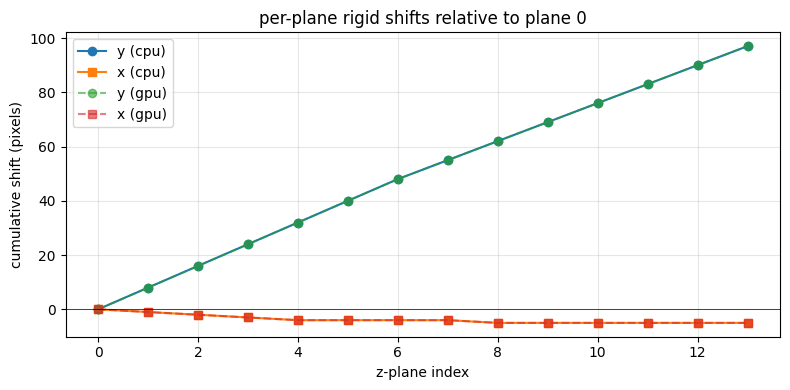

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
zs = np.arange(nz)
ax.plot(zs, tvecs_cpu[:, 0], "o-", label="y (cpu)")
ax.plot(zs, tvecs_cpu[:, 1], "s-", label="x (cpu)")
if tvecs_gpu is not None:
    ax.plot(zs, tvecs_gpu[:, 0], "o--", label="y (gpu)", alpha=0.6)
    ax.plot(zs, tvecs_gpu[:, 1], "s--", label="x (gpu)", alpha=0.6)
ax.set_xlabel("z-plane index")
ax.set_ylabel("cumulative shift (pixels)")
ax.set_title("per-plane rigid shifts relative to plane 0")
ax.axhline(0, color="k", lw=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. before/after shift (visual check)

rolls each plane by the computed shift and shows a z-max projection.
if shifts are correct, features that are misaligned across z in the raw
image should line up post-shift.

In [ ]:
def apply_shifts(im3d, tvecs):
    out = np.zeros_like(im3d)
    for z in range(im3d.shape[0]):
        dy, dx = int(round(tvecs[z, 0])), int(round(tvecs[z, 1]))
        out[z] = np.roll(im3d[z], (-dy, -dx), axis=(0, 1))
    return out

im3d_shifted = apply_shifts(im3d, tvecs_cpu)

raw_maxproj = im3d.max(axis=0)
shifted_maxproj = im3d_shifted.max(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vmin, vmax = np.percentile(raw_maxproj, [1, 99])
axes[0].imshow(raw_maxproj, vmin=vmin, vmax=vmax, cmap="gray")
axes[0].set_title("z-max projection (raw)")
axes[1].imshow(shifted_maxproj, vmin=vmin, vmax=vmax, cmap="gray")
axes[1].set_title("z-max projection (shifted)")
for a in axes:
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
# side-by-side of first / middle / last plane, raw vs shifted
show_planes = [0, nz // 2, nz - 1]
fig, axes = plt.subplots(2, len(show_planes), figsize=(4 * len(show_planes), 7))
for col, z in enumerate(show_planes):
    vmin, vmax = np.percentile(im3d[z], [1, 99])
    axes[0, col].imshow(im3d[z], vmin=vmin, vmax=vmax, cmap="gray")
    axes[0, col].set_title(f"z={z} raw")
    axes[1, col].imshow(im3d_shifted[z], vmin=vmin, vmax=vmax, cmap="gray")
    axes[1, col].set_title(f"z={z} shifted dy={int(tvecs_cpu[z, 0])} dx={int(tvecs_cpu[z, 1])}")
    for a in (axes[0, col], axes[1, col]):
        a.set_xticks([])
        a.set_yticks([])
plt.tight_layout()
plt.show()

## 9. benchmark

In [ ]:
print(f"source: {type(arr).__name__}  full shape: {tuple(arr.shape)}")
print(f"subsampled: {count} frames of {T}")
print(f"mean image: {im3d.shape}  ({im3d.nbytes / 1024**2:.2f} MB)")
print(f"load/stream: {t_load:.2f} s")
print(f"cpu align:   {t_cpu:.2f} s")
if t_gpu is not None:
    print(f"gpu align:   {t_gpu:.2f} s  ({t_cpu / t_gpu:.1f}x vs cpu)")
else:
    print("gpu align:   n/a")